In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
def euclideanDistance(p, q):
  return np.sqrt(np.sum((np.array(p) - np.array(q)) ** 2))

In [3]:
class KNN:
  def __init__(self, k=3):
    self.k = k
    self.X = None
    self.y = None

  def fit(self, X, y):
    self.X = X
    self.y = y

  def predict(self, X_test):
    return np.array([self.predict_one(x) for x in X_test])

  def predict_one(self, X):
    distances = []
    for i in range(len(self.X)):
      distance = euclideanDistance(self.X[i], X)
      distances.append((distance, self.y[i]))

    k_nearest = sorted(distances)[:self.k]
    k_labels = [label for dist, label in k_nearest]
    result = Counter(k_labels).most_common(1)[0][0]

    return result

In [4]:
data = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'],
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]
data = np.array(data)

points = {}

for row in data:
  x, y = row[0], row[1]
  label = row[3]

  if label not in points:
    points[label] = []

  points[label].append([x, y])

clean_points = {}

for label, coords in points.items():
    clean_label = str(label)  # to convert np.str_ -> normal python str

    clean_points[clean_label] = [
        [float(x), float(y)] for x, y in coords
    ]
points = clean_points
print(points)

{'Apple': [[150.0, 7.0], [155.0, 7.2], [145.0, 7.1]], 'Banana': [[120.0, 6.5], [110.0, 6.0], [115.0, 6.3]], 'Orange': [[180.0, 7.5], [190.0, 7.8]]}


In [5]:
X = data[:, :2].astype(float)
# X = (X - np.mean(X))/(np.std(X)) # Z-score Normalization
y = data[:, -1]

In [6]:
test_data = np.array([
    [118, 6.2, 0],  # Expected: Banana
    [160, 7.3, 1],  # Expected: Apple
    [185, 7.7, 2]   # Expected: Orange
])

X_test = test_data[:, :2].astype(float)
# X_test = (X_test - np.mean(X_test))/(np.std(X_test)) # Z-score Normalization
y_test = None

knn_classifier1 = KNN(k=3)
knn_classifier1.fit(X, y)
predictions = knn_classifier1.predict(X_test)

print(predictions)

['Banana' 'Apple' 'Orange']


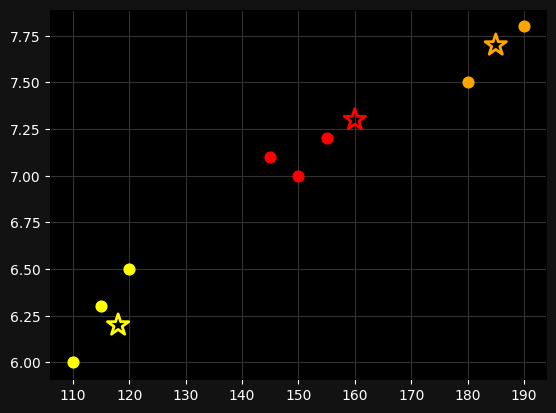

In [7]:
ax = plt.subplot()
ax.grid(True, color="#323232")
ax.set_facecolor("black")
ax.figure.set_facecolor("#121212")
ax.tick_params(axis='x', color='white', labelcolor='white')
ax.tick_params(axis='y', color='white', labelcolor='white')

for point in points['Apple']:
  ax.scatter(point[0], point[1], color="red", s=60, zorder=1000)

for point in points['Banana']:
  ax.scatter(point[0], point[1], color="yellow", s=60, zorder=1000)

for point in points['Orange']:
  ax.scatter(point[0], point[1], color="orange", s=60, zorder=1000)

for i, point in enumerate(X_test):
    predicted_label = predictions[i]
    if predicted_label == 'Apple': ax.scatter(point[0], point[1], marker="*", s=260, edgecolors='red', linewidths=2, zorder=100, facecolors='none')
    elif predicted_label == 'Banana': ax.scatter(point[0], point[1], marker="*", s=260, edgecolors='yellow', linewidths=2, zorder=100, facecolors='none')
    else: ax.scatter(point[0], point[1], marker="*", s=260, edgecolors='orange', linewidths=2, zorder=100, facecolors='none')


plt.show()

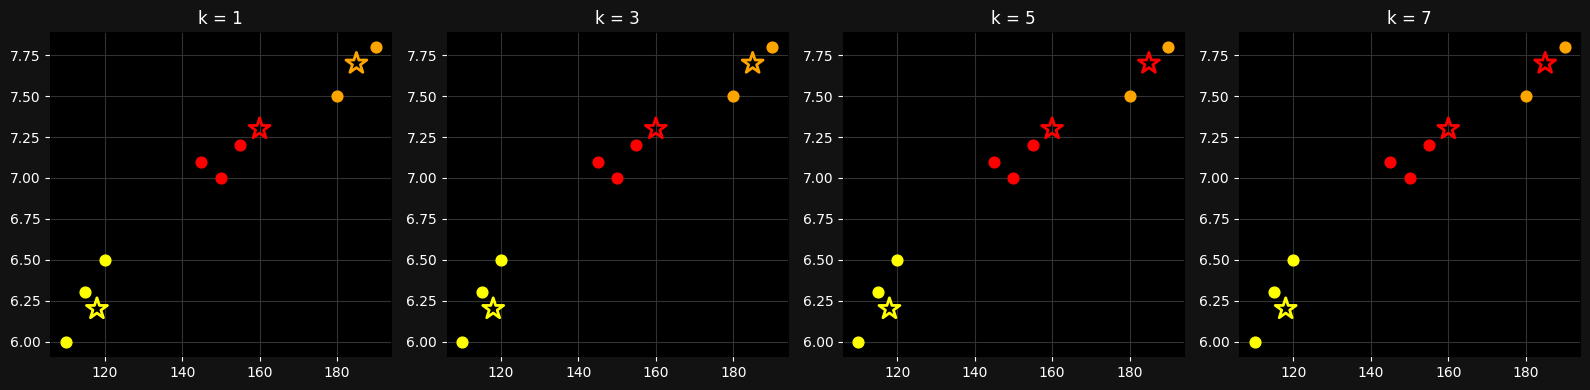

In [8]:
ks = [1, 3, 5, 7]
fig, axes = plt.subplots(1, len(ks), figsize=(16, 4))

color_map = {'Apple': 'red', 'Banana': 'yellow', 'Orange': 'orange'}

for ax, k in zip(axes, ks):

  knn_classifier = KNN(k=k)
  knn_classifier.fit(X, y)
  predictions = knn_classifier.predict(X_test)

  ax.grid(True, color="#323232")
  ax.set_facecolor("black")
  ax.set_title(f"k = {k}", color="white")
  ax.tick_params(axis='x', colors='white')
  ax.tick_params(axis='y', colors='white')

  for label, coords in points.items():
    for point in coords:
      ax.scatter(point[0], point[1], color=color_map[label], s=60, zorder=10)

  for i, point in enumerate(X_test):
    predicted_label = predictions[i]
    ax.scatter(point[0], point[1], marker='*', s=250,
              facecolors='none', edgecolors=color_map[predicted_label],
              linewidths=2, zorder=20)

fig.patch.set_facecolor("#121212")
plt.tight_layout()
plt.show()

# Performance Checker

We will test our performance using a few metrics such as:


1.   Accuracy (proportion of total correct predictions to all predictions made)
2.   Precision (ratio of true positives to all predicted positives)
3.   Recall (ratio of true positives to all actual positives)
4.   F1-Score (harmonic mean of precision and recall)

So,
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

where, $TP$ stands for True Positive, $TN$ stands for True Negative, $FP$ stands for False Positive, and $FN$ stands for False Negative.

In [9]:
y_true = np.array(['Banana', 'Apple', 'Orange'])

for k in ks:
  knn = KNN(k=k)
  knn.fit(X, y)
  y_pred = knn.predict(X_test)

  print(f"\nk = {k}")
  for cls in ['Apple', 'Banana', 'Orange']:
      TP = np.sum((y_pred == cls) & (y_true == cls))
      FP = np.sum((y_pred == cls) & (y_true != cls))
      FN = np.sum((y_pred != cls) & (y_true == cls))
      TN = np.sum((y_pred != cls) & (y_true != cls))

      accuracy = (TP + TN) / (TP + TN + FP + FN)
      precision = TP / (TP + FP) if (TP + FP) > 0 else 0
      recall = TP / (TP + FN) if (TP + FN) > 0 else 0
      f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

      print(f"{cls}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")
      print(f"  Accuracy={accuracy:.2f}, Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")
      print()
  print("-" * 20)



k = 1
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

--------------------

k = 3
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

--------------------

k = 5
Apple: TP=1, FP=1, FN=0, TN=1
  Accuracy=0.67, Precision=0.50, Recall=1.00, F1=0.67

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=0, FP=0, FN=1, TN=2
  Accuracy=0.67, Precision=0.00, Recall=0.00, F1=0.00

--------------------

k = 7
Apple: TP=1, FP=1, FN=0, TN=1
  Accuracy=0.67, Precision=0.50, Recall=1.00, F1=0.67

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Preci

# Weighted KNN

In a weighted KNN, closer neighbors have more voting power.
To implement this:

-    The weight can be the inverse of Euclidean distance to the neighbour
-    We will compute this weight for all the classes
-    The class with the greatest weight is the predicted class
-    We multiply this weight with the class (0, 1, 2)
-    Whichever class the final value is closest to, is the predicted class

In [10]:
class wKNN:
  def __init__(self, k=3):
    self.k = k
    self.X = None
    self.y = None

  def fit(self, X, y):
    self.X = X
    self.y = y

  def predict(self, X_test):
    return np.array([self.predict_one(x) for x in X_test])

  def predict_one(self, X):
    distances = []
    for i in range(len(self.X)):
      distance = euclideanDistance(self.X[i], X)
      distances.append((distance, self.y[i]))

    k_nearest = sorted(distances)[:self.k]

    class_weights = {}
    for dist, label in k_nearest:
      weight = 1 / (dist + 1e-10)
      if label not in class_weights:
        class_weights[label] = 0
      class_weights[label] += weight

    return max(class_weights, key=class_weights.get)

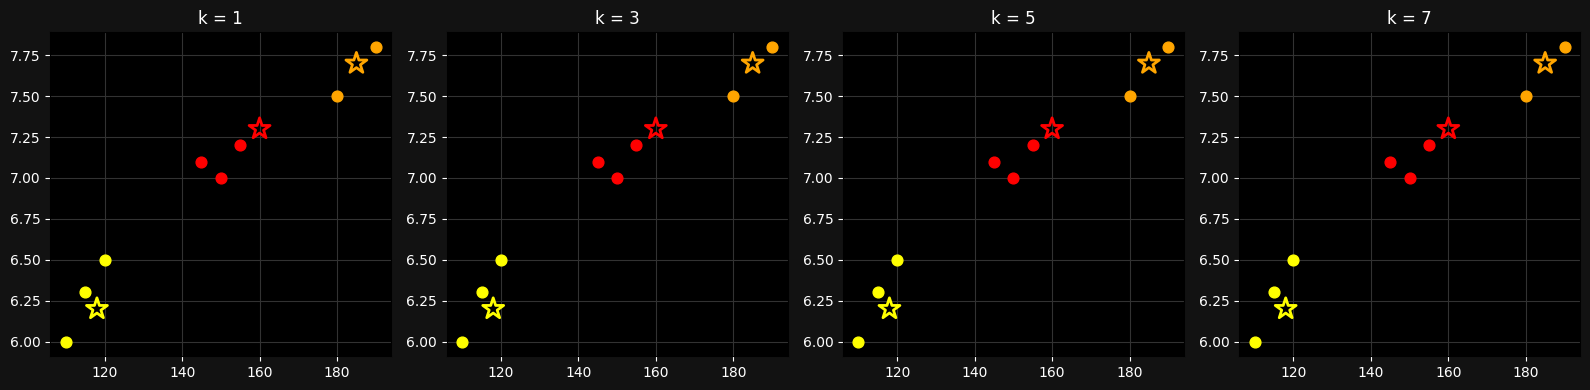

In [11]:
ks = [1, 3, 5, 7]
fig, axes = plt.subplots(1, len(ks), figsize=(16, 4))

color_map = {'Apple': 'red', 'Banana': 'yellow', 'Orange': 'orange'}

for ax, k in zip(axes, ks):

  knn_classifier = wKNN(k=k)
  knn_classifier.fit(X, y)
  predictions = knn_classifier.predict(X_test)

  ax.grid(True, color="#323232")
  ax.set_facecolor("black")
  ax.set_title(f"k = {k}", color="white")
  ax.tick_params(axis='x', colors='white')
  ax.tick_params(axis='y', colors='white')

  for label, coords in points.items():
    for point in coords:
      ax.scatter(point[0], point[1], color=color_map[label], s=60, zorder=10)

  for i, point in enumerate(X_test):
    predicted_label = predictions[i]
    ax.scatter(point[0], point[1], marker='*', s=250,
              facecolors='none', edgecolors=color_map[predicted_label],
              linewidths=2, zorder=20)

fig.patch.set_facecolor("#121212")
plt.tight_layout()
plt.show()

In [12]:
y_true = np.array(['Banana', 'Apple', 'Orange'])

for k in ks:
  knn = wKNN(k=k)
  knn.fit(X, y)
  y_pred = knn.predict(X_test)

  print(f"\nk = {k}")
  for cls in ['Apple', 'Banana', 'Orange']:
      TP = np.sum((y_pred == cls) & (y_true == cls))
      FP = np.sum((y_pred == cls) & (y_true != cls))
      FN = np.sum((y_pred != cls) & (y_true == cls))
      TN = np.sum((y_pred != cls) & (y_true != cls))

      accuracy = (TP + TN) / (TP + TN + FP + FN)
      precision = TP / (TP + FP) if (TP + FP) > 0 else 0
      recall = TP / (TP + FN) if (TP + FN) > 0 else 0
      f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

      print(f"{cls}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")
      print(f"  Accuracy={accuracy:.2f}, Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")
      print()
  print("-" * 20)



k = 1
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

--------------------

k = 3
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

--------------------

k = 5
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Orange: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

--------------------

k = 7
Apple: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Precision=1.00, Recall=1.00, F1=1.00

Banana: TP=1, FP=0, FN=0, TN=2
  Accuracy=1.00, Preci

## Clearly, the weighted KNN has performed better for k = 5, 7.